# Player Analysis
This notebook pulls NHL skater and roster data, builds player-level scoring tables, and visualizes league and team-specific scoring profiles.

In [42]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

## API Pull and Table Prep
Question: Can we reliably pull league skater leader data and shape it into a clean player table?

In [43]:
# Connect to our database
# Connect once and reuse for table writes/reads
conn = sqlite3.connect('../database/nhl.db')

# Pull skater stats from NHL API
skater_response = requests.get("https://api-web.nhle.com/v1/skater-stats-leaders/20252026/2?limit=-1")
print(skater_response.status_code)
print(skater_response.json().keys())

200
dict_keys(['goalsSh', 'plusMinus', 'assists', 'goalsPp', 'faceoffLeaders', 'penaltyMins', 'goals', 'points', 'toi'])


In [44]:
df_points = pd.DataFrame(skater_response.json()['points'])
df_points["first_name"] = df_points["firstName"].apply(lambda x: x['default'])
df_points["last_name"] = df_points["lastName"].apply(lambda x: x['default'])
df_points["team_name"] = df_points["teamName"].apply(lambda x: x['default'])
df_points = df_points.drop(columns=['headshot','teamLogo','firstName','lastName','teamName'])
df_points.rename(columns={'value': 'points'}, inplace=True)


df_goals = pd.DataFrame(skater_response.json()['goals'])
df_goals["first_name"] = df_goals["firstName"].apply(lambda x: x['default'])
df_goals["last_name"] = df_goals["lastName"].apply(lambda x: x['default'])
df_goals["team_name"] = df_goals["teamName"].apply(lambda x: x['default'])
df_goals = df_goals.drop(columns=['headshot','teamLogo','firstName','lastName','teamName'])
df_goals.rename(columns={'value': 'goals'}, inplace=True)
df_goals.head()

df_assists = pd.DataFrame(skater_response.json()['assists'])
df_assists["first_name"] = df_assists["firstName"].apply(lambda x: x['default'])
df_assists["last_name"] = df_assists["lastName"].apply(lambda x: x['default'])
df_assists["team_name"] = df_assists["teamName"].apply(lambda x: x['default'])
df_assists = df_assists.drop(columns=['headshot','teamLogo','firstName','lastName','teamName'])
df_assists.rename(columns={'value': 'assist'}, inplace=True)

df_assists.head()

,id,sweaterNumber,teamAbbrev,position,assist,first_name,last_name,team_name
0,8478402,97.0,EDM,C,90,Connor,McDavid,Oilers
1,8476453,86.0,TBL,R,86,Nikita,Kucherov,Lightning
2,8477492,29.0,COL,C,74,Nathan,MacKinnon,Avalanche
3,8480803,2.0,EDM,D,74,Evan,Bouchard,Oilers
4,8480018,14.0,MTL,C,72,Nick,Suzuki,Canadiens


In [45]:
# Merge category leaderboards (points, goals, assists) into one player table
df_players = pd.merge(df_points, df_goals, on='id')
df_players = pd.merge(df_players, df_assists, on='id')

In [46]:
df_players.columns

Index(['id', 'sweaterNumber_x', 'teamAbbrev_x', 'position_x', 'points',
       'first_name_x', 'last_name_x', 'team_name_x', 'sweaterNumber_y',
       'teamAbbrev_y', 'position_y', 'goals', 'first_name_y', 'last_name_y',
       'team_name_y', 'sweaterNumber', 'teamAbbrev', 'position', 'assist',
       'first_name', 'last_name', 'team_name'],
      dtype='str')

In [47]:
df_players = df_players[['id', 'first_name_x', 'last_name_x', 'teamAbbrev_x', 'position_x', 'points', 'goals', 'assist']]

df_players.rename(columns={
    'first_name_x': 'first_name',
    'last_name_x': 'last_name',
    'teamAbbrev_x': 'team',
    'position_x': 'position',
    'assist': 'assists'
}, inplace=True)

print(df_players.shape)
df_players.head()

(718, 8)


,id,first_name,last_name,team,position,points,goals,assists
0,8478402,Connor,McDavid,EDM,C,138,48,90
1,8476453,Nikita,Kucherov,TBL,R,130,44,86
2,8477492,Nathan,MacKinnon,COL,C,127,53,74
3,8484801,Macklin,Celebrini,SJS,C,115,45,70
4,8476460,Mark,Scheifele,WPG,C,103,36,67


In [48]:
df_players.to_sql('players', conn, if_exists='replace', index=False)
print("Players table written to database!")

Players table written to database!


## Persist and Query Player Table
Question: Who are the top point producers after storing the cleaned player table?

In [49]:
query = """
    SELECT first_name, last_name, team, position, points, goals, assists
    FROM players
    ORDER BY points DESC
"""

df_player_query = pd.read_sql_query(query, conn)
df_player_query.head(10)

,first_name,last_name,team,position,points,goals,assists
0,Connor,McDavid,EDM,C,138,48,90
1,Nikita,Kucherov,TBL,R,130,44,86
2,Nathan,MacKinnon,COL,C,127,53,74
3,Macklin,Celebrini,SJS,C,115,45,70
4,Mark,Scheifele,WPG,C,103,36,67
5,Nick,Suzuki,MTL,C,101,29,72
6,Martin,Necas,COL,C,100,38,62
7,David,Pastrnak,BOS,R,100,29,71
8,Leon,Draisaitl,EDM,C,97,35,62
9,Jason,Robertson,DAL,L,96,45,51


## Experience Context
Player tenure metadata can be added later for deeper context on over- and under-performance.

## Visualization: Top Points Leaders
Question: Which top-20 scorers lead in total points, and how does position distribution look among them?

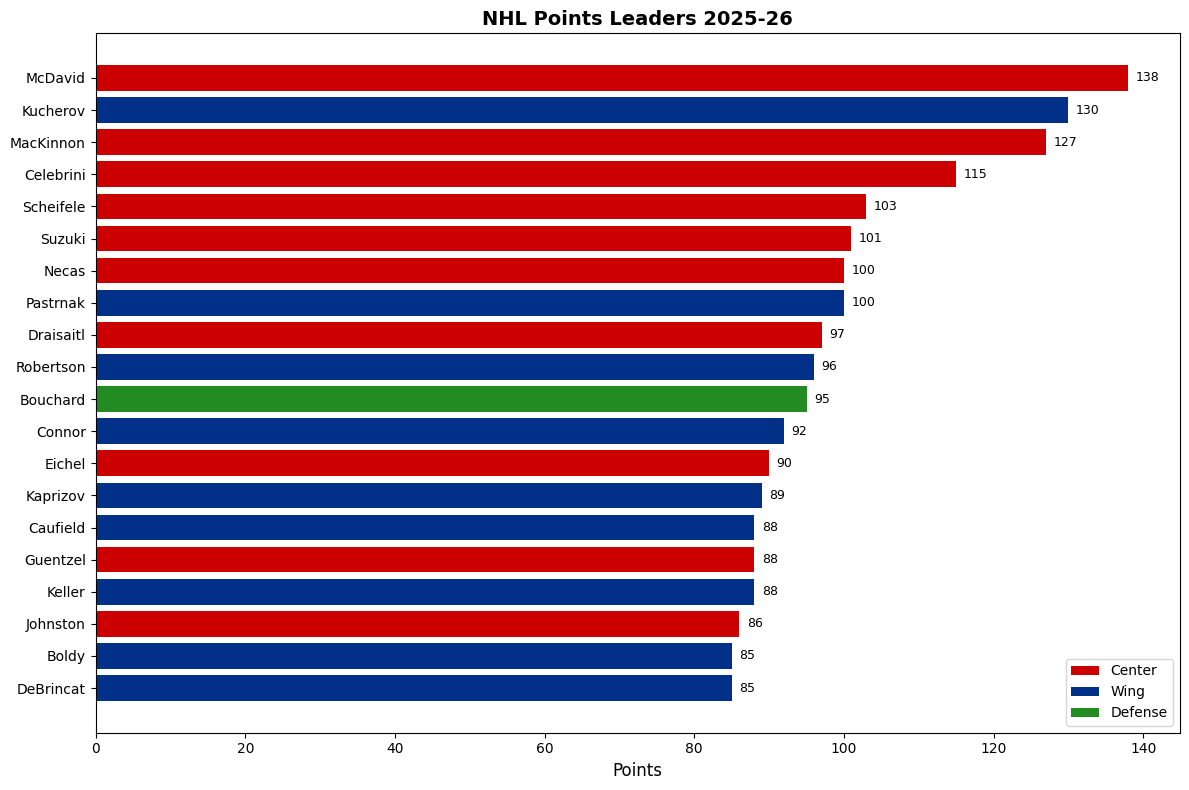

In [50]:
df_top20 = df_player_query.head(20).sort_values('points', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#CC0000' if pos == 'C' else '#003087' if pos == 'L' or pos == 'R' else '#228B22' 
          for pos in df_top20['position']]
ax.barh(df_top20['last_name'], df_top20['points'], color=colors)

ax.set_title('NHL Points Leaders 2025-26', fontsize=14, fontweight='bold')
ax.set_xlabel('Points', fontsize=12)

colors = ['#CC0000' if pos == 'C' else '#003087' if pos == 'L' or pos == 'R' else '#228B22' 
          for pos in df_top20['position']]

for i, val in enumerate(df_top20['points']):
    ax.text(val + 1, i, str(val), va='center', fontsize=9)

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor='#CC0000', label='Center'),
    Patch(facecolor='#003087', label='Wing'),
    Patch(facecolor='#228B22', label='Defense')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('../visuals/05_points_leaders.png', dpi=150, bbox_inches='tight')

plt.show()

## Visualization: Goals vs Assists Mix
Question: Are top point leaders driven more by goal scoring or by playmaking assists?

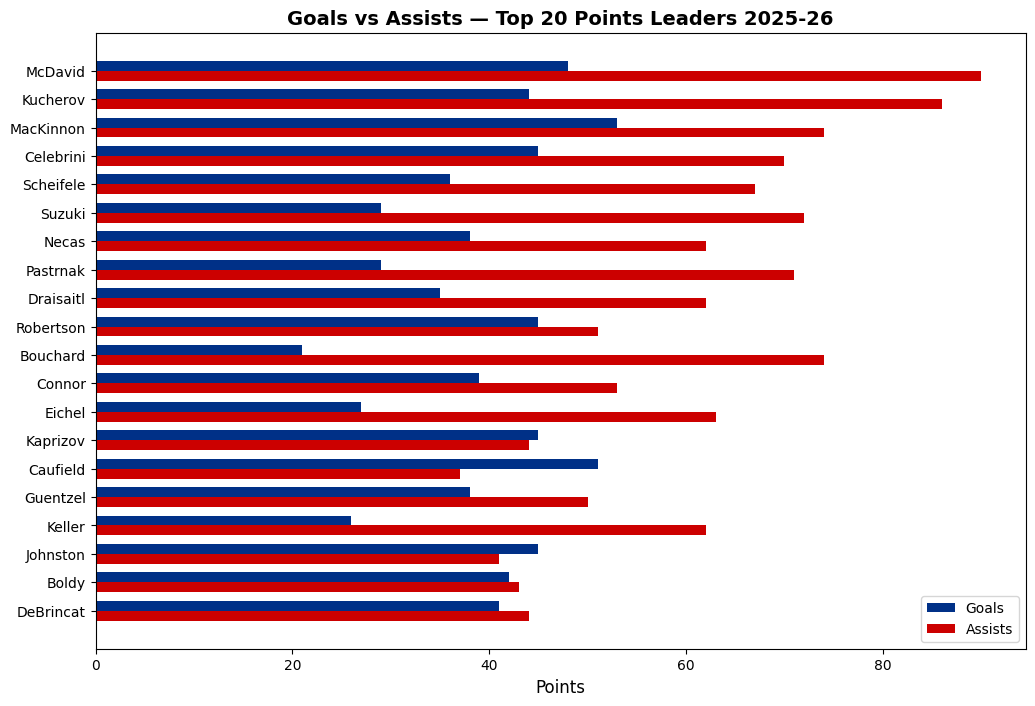

In [51]:
df_top20 = df_player_query.head(20).sort_values('points', ascending=True)

bar_width = 0.35
y = range(len(df_top20))

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_title('NHL Points Leaders 2025-26', fontsize=14, fontweight='bold')
ax.set_xlabel('Points', fontsize=12)


goal_bars = ax.barh([i + bar_width/2 for i in y], df_top20['goals'], 
                     height=bar_width, label='Goals', color='#003087')
assist_bars = ax.barh([i - bar_width/2 for i in y], df_top20['assists'], 
                     height=bar_width, label='Assists', color='#CC0000')

ax.set_yticks(y)
ax.set_yticklabels(df_top20['last_name'])
ax.legend()

from matplotlib.patches import Patch


ax.set_title('Goals vs Assists — Top 20 Points Leaders 2025-26', fontsize=14, fontweight='bold')
plt.savefig('../visuals/06_goals_vs_assists.png', dpi=150, bbox_inches='tight')

plt.show()

## Penguins Roster Deep Dive
Question: How does Pittsburgh's roster scoring profile break down by player and contribution type?
This section focuses on roster-level performance analysis for Pittsburgh and compares skater contribution patterns.

In [52]:

response_pit = requests.get("https://api-web.nhle.com/v1/roster/PIT/20252026")
print(response_pit.status_code)
print(response_pit.json().keys())

200
dict_keys(['forwards', 'defensemen', 'goalies'])


In [53]:
response_pit.json()["forwards"][0]

{'id': 8478569,
 'headshot': 'https://assets.nhle.com/mugs/nhl/20252026/PIT/8478569.png',
 'firstName': {'default': 'Noel'},
 'lastName': {'default': 'Acciari'},
 'sweaterNumber': 55,
 'positionCode': 'C',
 'shootsCatches': 'R',
 'heightInInches': 71,
 'weightInPounds': 204,
 'heightInCentimeters': 180,
 'weightInKilograms': 93,
 'birthDate': '1991-12-01',
 'birthCity': {'default': 'Johnston'},
 'birthCountry': 'USA',
 'birthStateProvince': {'default': 'RI'}}

In [54]:
df_forwards = pd.DataFrame(response_pit.json()['forwards'])
df_forwards["first_name"] = df_forwards["firstName"].apply(lambda x: x['default'])
df_forwards["last_name"] = df_forwards["lastName"].apply(lambda x: x['default'])
df_forwards = df_forwards.drop(columns=["headshot", "birthCity", "birthStateProvince", "firstName", "lastName"])

df_defense = pd.DataFrame(response_pit.json()['defensemen'])
df_defense["first_name"] = df_defense["firstName"].apply(lambda x: x['default'])
df_defense["last_name"] = df_defense["lastName"].apply(lambda x: x['default'])
df_defense = df_defense.drop(columns=["headshot", "birthCity", "birthStateProvince", "firstName", "lastName"])

df_goalies = pd.DataFrame(response_pit.json()['goalies'])
df_goalies["first_name"] = df_goalies["firstName"].apply(lambda x: x['default'])
df_goalies["last_name"] = df_goalies["lastName"].apply(lambda x: x['default'])
df_goalies = df_goalies.drop(columns=["headshot", "birthCity", "birthStateProvince", "firstName", "lastName"])

df_forwards['group'] = 'forward'
df_defense['group'] = 'defense'
df_goalies['group'] = 'goalie'

df_pit = pd.concat([df_forwards, df_defense, df_goalies], ignore_index=True)

df_pit.head()

,id,sweaterNumber,positionCode,shootsCatches,heightInInches,weightInPounds,heightInCentimeters,weightInKilograms,birthDate,birthCountry,first_name,last_name,group
0,8478569,55,C,R,71,204,180,93,1991-12-01,USA,Noel,Acciari,forward
1,8479638,16,R,R,78,232,198,105,1998-02-02,CAN,Justin,Brazeau,forward
2,8482475,59,R,L,73,203,185,92,2001-02-01,RUS,Egor,Chinakhov,forward
3,8471675,87,C,L,71,200,180,91,1987-08-07,CAN,Sidney,Crosby,forward
4,8480980,19,C,L,70,187,178,85,1999-06-26,CAN,Connor,Dewar,forward


In [55]:
df_pit_merged = pd.merge(df_pit, df_players, on='id', how='left')

In [56]:
df_pit_stats = df_pit_merged[[
    'id', 'first_name_x', 'last_name_x', 'sweaterNumber', 
    'positionCode', 'group', 'birthCountry', 'heightInInches', 
    'weightInPounds', 'birthDate', 'points', 'goals', 'assists'
]]

df_pit_stats.rename(columns={
    'first_name_x': 'first_name',
    'last_name_x': 'last_name',
    'positionCode': 'position',
    'sweaterNumber': 'number'
}, inplace=True)

# Fill NaN stats with 0 for players with no scoring
df_pit_stats[['points', 'goals', 'assists']] = df_pit_stats[['points', 'goals', 'assists']].fillna(0)

df_pit_stats.head()

,id,first_name,last_name,number,position,group,birthCountry,heightInInches,weightInPounds,birthDate,points,goals,assists
0,8478569,Noel,Acciari,55,C,forward,USA,71,204,1991-12-01,25.0,13.0,12.0
1,8479638,Justin,Brazeau,16,R,forward,CAN,78,232,1998-02-02,34.0,17.0,17.0
2,8482475,Egor,Chinakhov,59,R,forward,RUS,73,203,2001-02-01,42.0,21.0,21.0
3,8471675,Sidney,Crosby,87,C,forward,CAN,71,200,1987-08-07,74.0,29.0,45.0
4,8480980,Connor,Dewar,19,C,forward,CAN,70,187,1999-06-26,30.0,14.0,16.0


In [57]:
df_pit_stats.to_sql('penguins_roster', conn, if_exists='replace', index=False)
print("Penguins roster written to database!")

Penguins roster written to database!


In [58]:
df_pit_skaters = df_pit_stats[df_pit_stats['group'] != 'goalie'].sort_values('points', ascending=True)

## Visualization: Penguins Goals vs Assists
Question: Which Penguins skaters are primarily goal scorers versus assist-driven contributors?

26


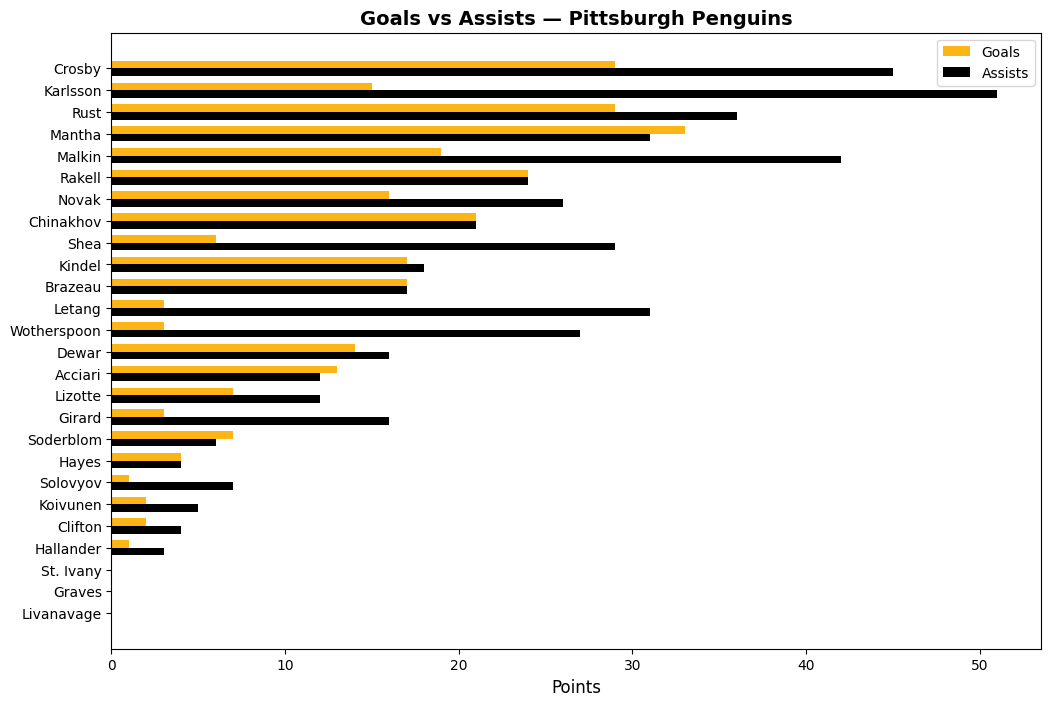

In [59]:
df_pit_skaters = df_pit_skaters.sort_values('points', ascending=True)

print(len(df_pit_skaters))

bar_width = 0.35
y = range(len(df_pit_skaters))

fig, ax = plt.subplots(figsize=(12, 8))

ax.set_xlabel('Points', fontsize=12)


goal_bars = ax.barh([i + bar_width/2 for i in y], df_pit_skaters['goals'], 
                     height=bar_width, label='Goals', color='#FCB514')
assist_bars = ax.barh([i - bar_width/2 for i in y], df_pit_skaters['assists'], 
                     height=bar_width, label='Assists', color='#000000')

ax.set_yticks(y)
ax.set_yticklabels(df_pit_skaters['last_name'])
ax.legend()

from matplotlib.patches import Patch


ax.set_title('Goals vs Assists — Pittsburgh Penguins', fontsize=14, fontweight='bold')
plt.savefig('../visuals/07_penguins_goals_vs_assists.png', dpi=150, bbox_inches='tight')

plt.show()